# Hotel No-Show Prediction

<p align="center">
  <img src="images/final_results_header.png" alt="Hotel no-show prediction report visual" width="1200"/>
</p>

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not ((PROJECT_ROOT / "src").exists() and (PROJECT_ROOT / "conf").exists()):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root containing src/ and conf/.")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "notebooks"))

import final_results_helpers

importlib.reload(final_results_helpers)

from final_results_helpers import (
    load_report_context,
    plot_calibration_curve,
    plot_cv_results,
    plot_precision_recall_curve,
    plot_roc_curve,
    plot_target_distribution,
    summarise_candidate_pipelines,
    summarize_dataset,
    summarize_prediction_features,
    summarize_selected_pipeline,
    set_report_theme,
)

set_report_theme()
report = load_report_context(PROJECT_ROOT)
data = report.data
latest_run = report.latest_run
cv_results = report.cv_results
y_test = report.y_test
y_score = report.y_score
target_column = report.target_column

/Users/Hardisk_WeiFeng/Hotel No Show Prediction/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:177: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance.
  return FileStore(store_uri, store_uri)


/Users/Hardisk_WeiFeng/Hotel No Show Prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/Hardisk_WeiFeng/Hotel No Show Prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/Hardisk_WeiFeng/Hotel No Show Prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/Hardisk_WeiFeng/Hotel No Show Prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/Hardisk_WeiFeng/Hotel No Show Prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 1. Project Objective
In this project, we leverage machine learning to accurately predict the probability that a hotel guest will show up for their booked stay ('0'), or if a no-show will occur ('1').

These probabilistic predictions are valuable as they can help inform hotel operations decisions, such as staffing, inventory management, reminder campaigns, deposit policies, and overbooking limits, so as to optimize business objectives such as profit.

## 2. Workflow Stages

To achieve the project objective, a machine learning workflow consisting of the following stages was developed, starting with the dataset noshow.db:

`noshow.db -> data ingestion -> data cleaning and validation -> feature engineering -> train/test split -> ML experiment -> pipeline selection and calibration -> holdout evaluation and results`

Note: a scikit-learn pipeline is composed of a preprocessor, which feeds engineered and preprocessed features to a machine learning model with specific hyperparameters to make a prediction.


## 3. Data Overview

Data shape after data cleaning, data validation and feature engineering:

In [2]:
summarize_dataset(data, target_column)

,item,value
0,rows,119390
1,columns,24
2,target column,no_show


The distribution of the target variable 'no_show':

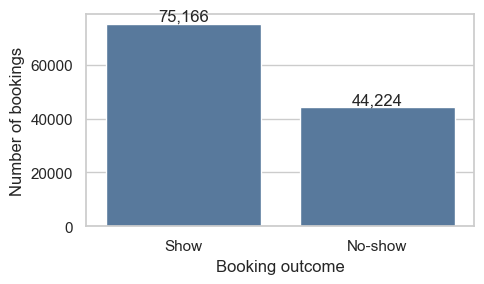

In [3]:
fig, ax = plt.subplots(figsize=(5, 3))
plot_target_distribution(data, target_column, ax)
fig.tight_layout()

Features available in the dataset, including engineered features:

In [4]:
summarize_prediction_features(PROJECT_ROOT, data)

,feature_group,feature,dtype
0,numeric type,arrival_day,Int64
1,numeric type,checkout_day,Int64
2,numeric type,num_adults,Int64
3,numeric type,num_children,Int64
4,numeric type,price_amount_sgd,float64
5,numeric type,stay_length_nights,float64
6,numeric type,booking_to_arrival_month_gap,int64
7,numeric type,total_guests,Int64
8,numeric type,price_per_guest,Float64
9,numeric type,price_per_night,float64


## 4. ML Experiment 

In the ML experiment, candidate pipelines were evaluated on the train set (80%) using a stratified 5-fold cross validation strategy. Each candidate pipeline consists of `preprocessor_v1`, which feeds preprocessed features to a machine learning model (RandomForest, LightGBM, or XGBoost), with specific hyperparameters. The mean cross-validated AUROC was used to compare the ability of candidate pipelines to discriminate between instances of 'show' vs 'no-show'.

In [5]:
summarise_candidate_pipelines(cv_results)

rank_test_score,mean_test_score,candidate_pipeline
1,0.807,"preprocessor_v1 + LightGBM: n_estimators=300, learning_rate=0.05, min_child_samples=20.0, num_leaves=127.0"
2,0.805,"preprocessor_v1 + LightGBM: n_estimators=300, learning_rate=0.05, min_child_samples=50.0, num_leaves=127.0"
3,0.805,"preprocessor_v1 + RandomForest: max_depth=None, max_features=sqrt, min_samples_leaf=1.0, n_estimators=200"
4,0.805,"preprocessor_v1 + LightGBM: n_estimators=300, learning_rate=0.1, min_child_samples=20.0, num_leaves=127.0"
5,0.805,"preprocessor_v1 + LightGBM: n_estimators=100, learning_rate=0.1, min_child_samples=20.0, num_leaves=127.0"
6,0.804,"preprocessor_v1 + LightGBM: n_estimators=100, learning_rate=0.1, min_child_samples=50.0, num_leaves=127.0"
7,0.804,"preprocessor_v1 + LightGBM: n_estimators=300, learning_rate=0.1, min_child_samples=50.0, num_leaves=127.0"
8,0.803,"preprocessor_v1 + RandomForest: max_depth=None, max_features=log2, min_samples_leaf=1.0, n_estimators=200"
9,0.803,"preprocessor_v1 + RandomForest: max_depth=None, max_features=sqrt, min_samples_leaf=5.0, n_estimators=200"
10,0.803,"preprocessor_v1 + RandomForest: max_depth=None, max_features=sqrt, min_samples_leaf=1.0, n_estimators=100"


## 5. Pipeline Selection and Calibration

From the ML experiment, the best candidate pipeline was selected based on the highest mean cross-validated AUROC.  It was then calibrated on the train set (80%) using isotonic regression to ensure accurate probabilistic predictions.

In [6]:
summarize_selected_pipeline(latest_run)

,component,detail,value
0,preprocessor,selected preprocessor,ColumnTransformer
1,model,selected model,LGBMClassifier
2,hyperparameter,learning_rate,0.05
3,hyperparameter,max_depth,None
4,hyperparameter,max_features,None
5,hyperparameter,min_child_samples,20
6,hyperparameter,n_estimators,300
7,hyperparameter,num_leaves,127


## 6. Holdout Evaluation and Results

The calibrated pipeline was evaluated on the test set (20%). Metrics such as AUROC, AUPRC and Brier score were computed to quantify its predictive performance. Correspondingly, visualisations such as the ROC curve, precision-recall curve, and calibration curve were created to aid in the selection of a suitable classification threshold.

### ROC Curve

First, we plot the ROC curve to visualise the tradeoff between True Positive Rate and False Positive Rate across various classification thresholds.

True Positive Rate measures the proportion of actual no-shows that were predicted as no-shows. A higher True Positive Rate means that more no-show instances will be identified in advance and receive intervention. False Positive Rate measures the proportion of actual shows that were incorrectly predicted as no-shows. A higher False Positive Rate means that more guests who would have shown up may receive unnecessary interventions.

For example, at the classification threshold where 60% of all no-show instances are identified (True Positive Rate = 0.60), around 15% of show instances are incorrectly predicted as no-shows (False Positive Rate = 0.15).

Overall, the pipeline achieves an AUROC of 0.81, indicating that no-show instances are assigned higher no-show probabilities than show instances around 81% of the time, allowing robust discrimination between the two.

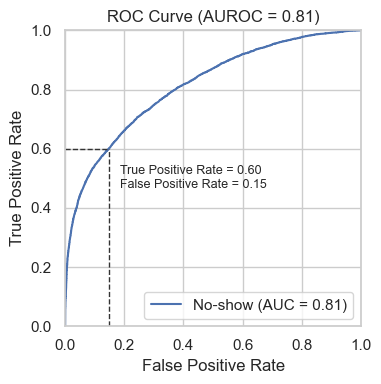

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_roc_curve(y_test, y_score, ax)
fig.tight_layout()

### Precision-Recall Curve

Moreover, we plot the precision-recall curve to visualise the tradeoff between Precision and Recall across various classification thresholds.

Precision measures the proportion of predicted no-shows which are actually no-shows. Higher precision means that a larger proportion of interventions will be targeted at actual no-shows. 

For example, at the classification threshold where 60% of all no-shows are identified (Recall = 0.60), around 71% of the predicted no-shows are actually no-shows (Precision = 0.71).

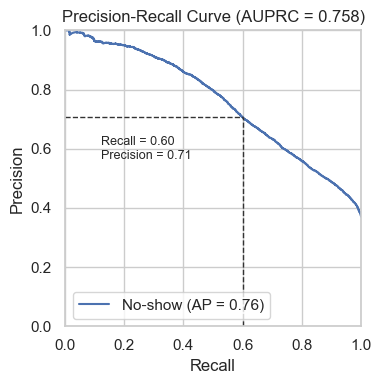

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_precision_recall_curve(y_test, y_score, ax)
fig.tight_layout()

### Calibration Curve

Lastly, we plot the calibration curve to assess whether the predicted no-show probabilities align with the actual observed no-show rates.

This is important because well-calibrated probabilities enable reliable estimation of operational quantities such as expected no-shows, expected show-ups, under-occupancy risk, over-occupancy risk, and the potential value of targeted interventions such as reminders. 

These estimates can then inform hotel operations decisions, including staffing, inventory management, reminder campaigns, deposit policies, and overbooking limits, so as to optimize business objectives such as profit.

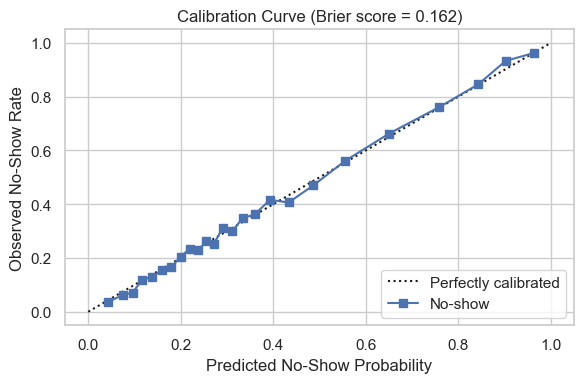

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_calibration_curve(y_test, y_score, ax)
fig.tight_layout()